In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
import pandas as pd

df = pd.read_csv("../data/interim/cleaned_day2.csv")

df.head()

,SKU_ID,Category,ABC_Class,Supplier_Name,Warehouse_Location,Received_Date,Last_Purchase_Date,Stock_Age_Days,Quantity_On_Hand,Damaged_Qty,Returns_Qty,Avg_Daily_Sales,Forecast_Next_30d,Reorder_Point,Safety_Stock,Lead_Time_Days,Total_Inventory_Value_USD,Supplier_OnTime_Pct,Inventory_Status
0,SKU_14996,Household,A,NextGen Traders,Chennai Warehouse,2024-06-11 00:00:00,2024-07-11,212,482.0,13,9,19.84,459.32,126,47,7.0,45555.63,82.64,Normal
1,SKU_10247,Snacks,C,NextGen Traders,Bangalore Warehouse,2024-11-24 00:00:00,2025-03-19,357,640.0,8,6,34.81,1072.54,110,75,5.0,36577.48,94.58,Normal
2,SKU_16215,Dairy,C,NextGen Traders,Chennai Warehouse,2023-02-01 00:00:00,2023-03-06,104,538.0,5,3,49.66,1891.81,118,66,12.0,23742.67,98.22,Overstock
3,SKU_13545,Bakery,A,Prime Distribution,Chennai Warehouse,2024-03-13 00:00:00,2024-06-04,161,530.0,9,2,20.00,662.42,119,11,8.0,49287.57,97.45,Low Stock
4,SKU_15397,Produce,B,Global Retail Supply,Chennai Warehouse,2023-05-01 00:00:00,2023-05-09,289,397.0,14,3,32.63,1115.41,128,42,3.0,16929.86,86.75,Overstock


In [31]:
df.head()

,SKU_ID,Category,ABC_Class,Supplier_Name,Warehouse_Location,Received_Date,Last_Purchase_Date,Stock_Age_Days,Quantity_On_Hand,Damaged_Qty,Returns_Qty,Avg_Daily_Sales,Forecast_Next_30d,Reorder_Point,Safety_Stock,Lead_Time_Days,Total_Inventory_Value_USD,Supplier_OnTime_Pct,Inventory_Status
0,SKU_14996,Household,A,NextGen Traders,Chennai Warehouse,2024-06-11 00:00:00,2024-07-11,212,482.0,13,9,19.84,459.32,126,47,7.0,45555.63,82.64,Normal
1,SKU_10247,Snacks,C,NextGen Traders,Bangalore Warehouse,2024-11-24 00:00:00,2025-03-19,357,640.0,8,6,34.81,1072.54,110,75,5.0,36577.48,94.58,Normal
2,SKU_16215,Dairy,C,NextGen Traders,Chennai Warehouse,2023-02-01 00:00:00,2023-03-06,104,538.0,5,3,49.66,1891.81,118,66,12.0,23742.67,98.22,Overstock
3,SKU_13545,Bakery,A,Prime Distribution,Chennai Warehouse,2024-03-13 00:00:00,2024-06-04,161,530.0,9,2,20.00,662.42,119,11,8.0,49287.57,97.45,Low Stock
4,SKU_15397,Produce,B,Global Retail Supply,Chennai Warehouse,2023-05-01 00:00:00,2023-05-09,289,397.0,14,3,32.63,1115.41,128,42,3.0,16929.86,86.75,Overstock


In [32]:
df.shape

(6700, 19)

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6700 entries, 0 to 6699
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   SKU_ID                     6700 non-null   str    
 1   Category                   6700 non-null   str    
 2   ABC_Class                  6700 non-null   str    
 3   Supplier_Name              6700 non-null   str    
 4   Warehouse_Location         6700 non-null   str    
 5   Received_Date              6700 non-null   str    
 6   Last_Purchase_Date         6700 non-null   str    
 7   Stock_Age_Days             6700 non-null   int64  
 8   Quantity_On_Hand           6700 non-null   float64
 9   Damaged_Qty                6700 non-null   int64  
 10  Returns_Qty                6700 non-null   int64  
 11  Avg_Daily_Sales            6700 non-null   float64
 12  Forecast_Next_30d          6700 non-null   float64
 13  Reorder_Point              6700 non-null   int64  
 14  Saf

In [34]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

numeric_cols

Index(['Stock_Age_Days', 'Quantity_On_Hand', 'Damaged_Qty', 'Returns_Qty',
       'Avg_Daily_Sales', 'Forecast_Next_30d', 'Reorder_Point', 'Safety_Stock',
       'Lead_Time_Days', 'Total_Inventory_Value_USD', 'Supplier_OnTime_Pct'],
      dtype='str')

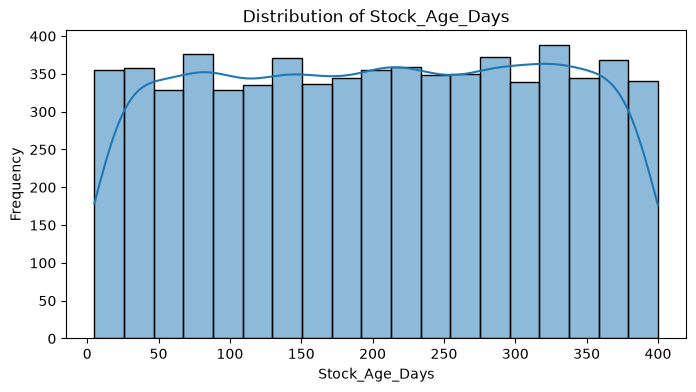

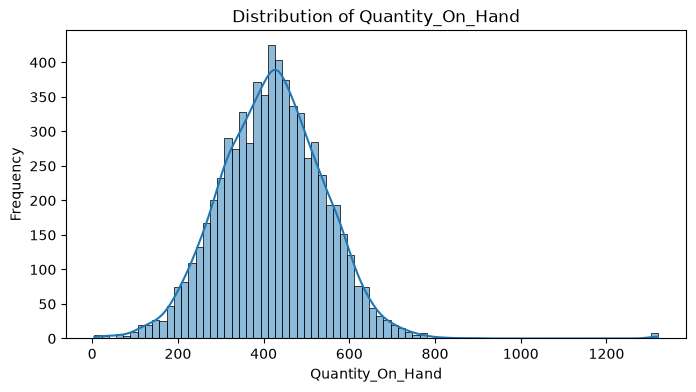

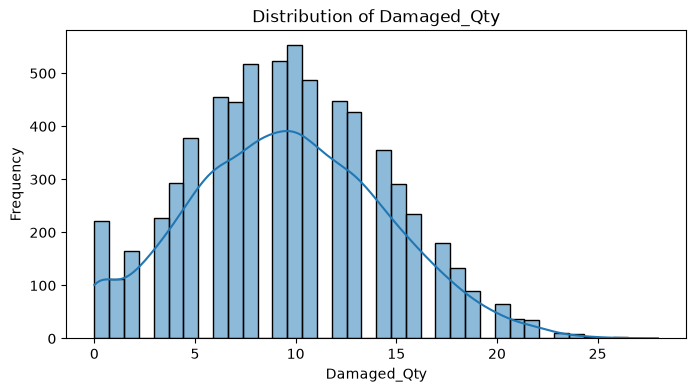

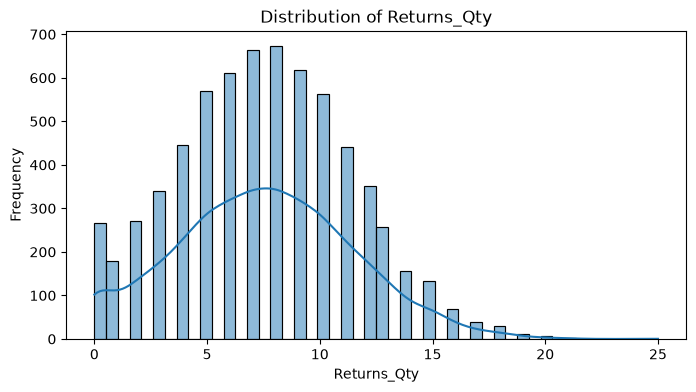

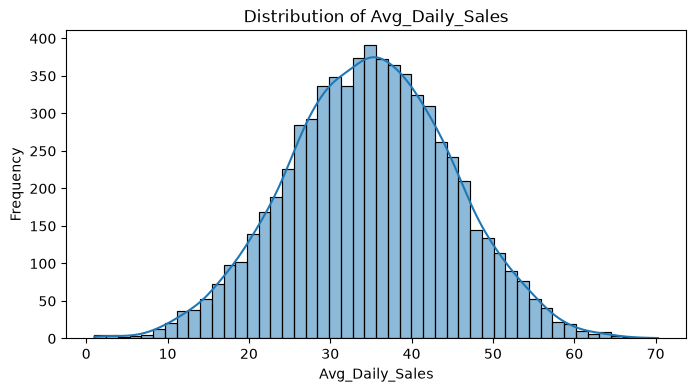

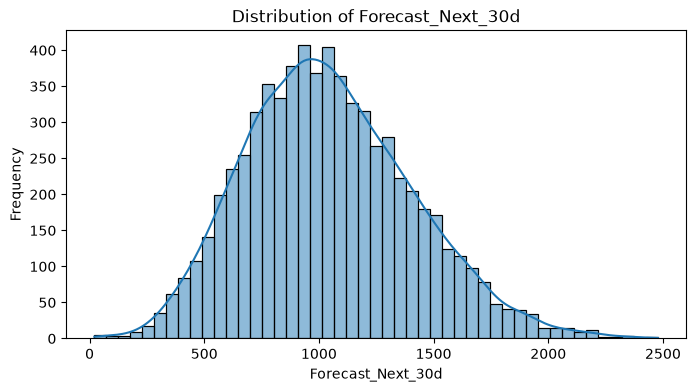

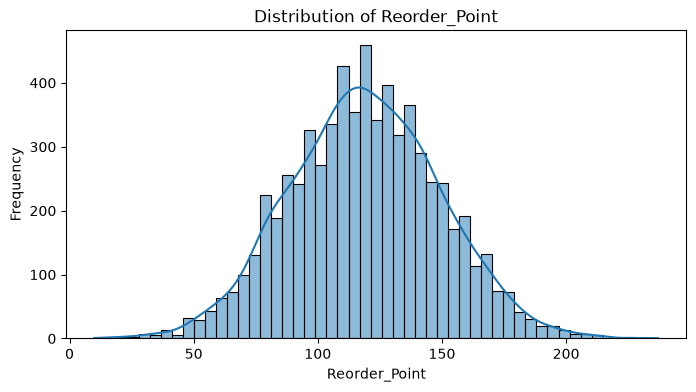

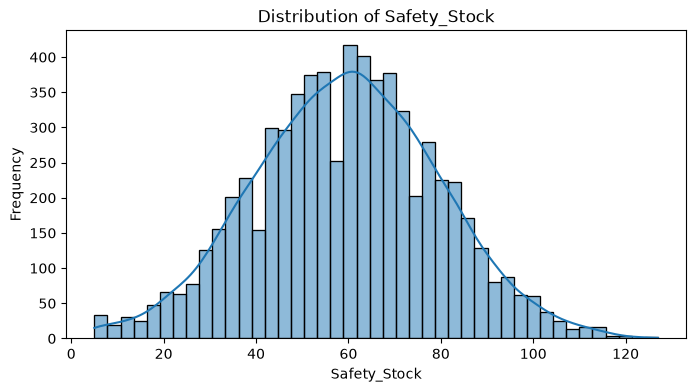

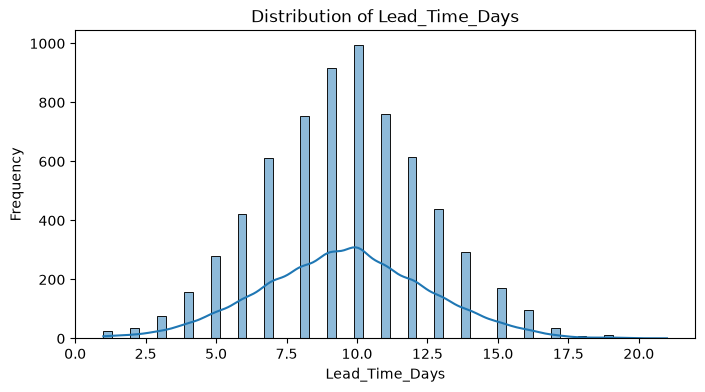

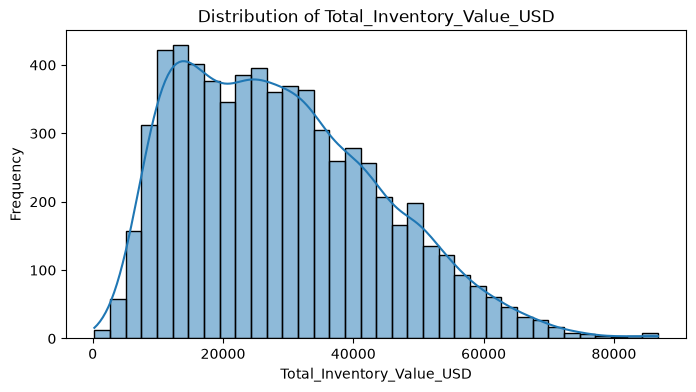

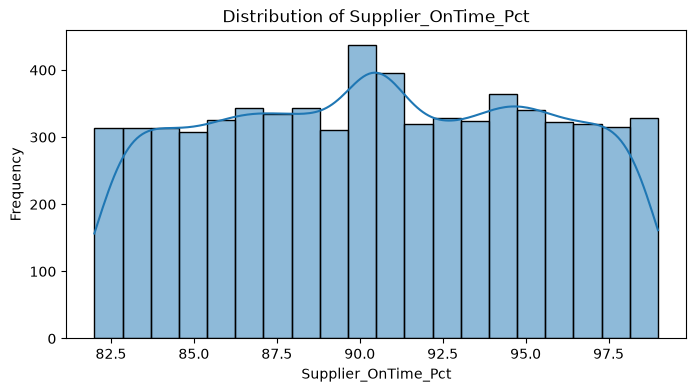

In [35]:
for col in numeric_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.histplot(
        data=df,
        x=col,
        kde=True
    )
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    
    plt.savefig(f"../reports/figures/{col}_histogram.png")
    
    plt.show()

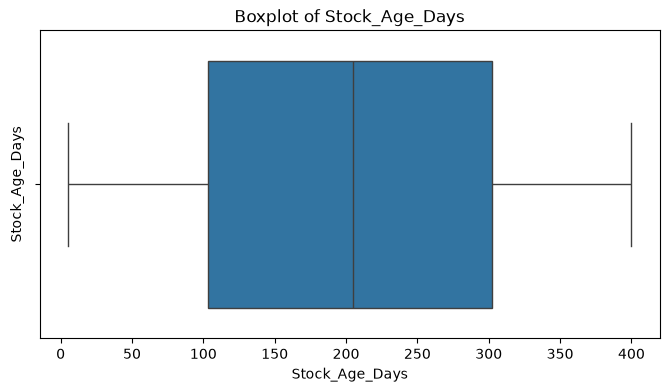

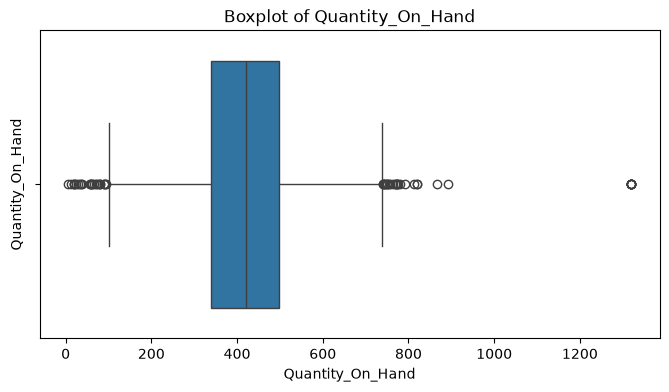

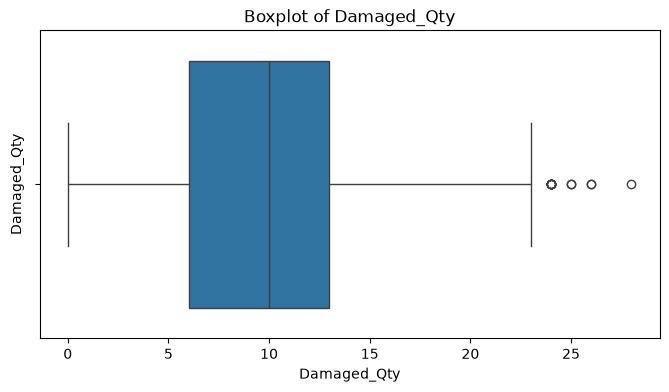

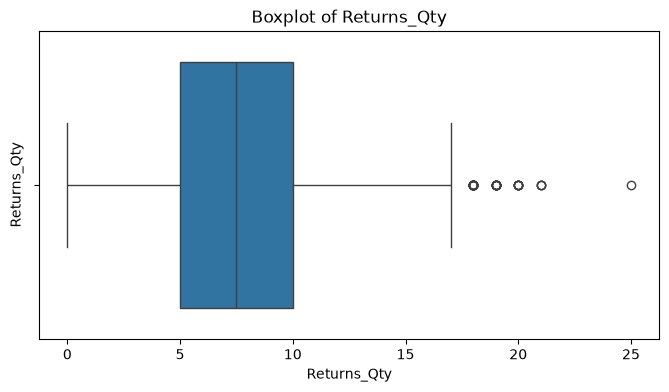

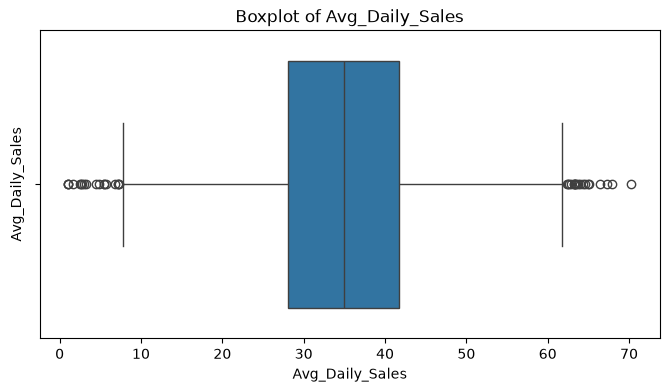

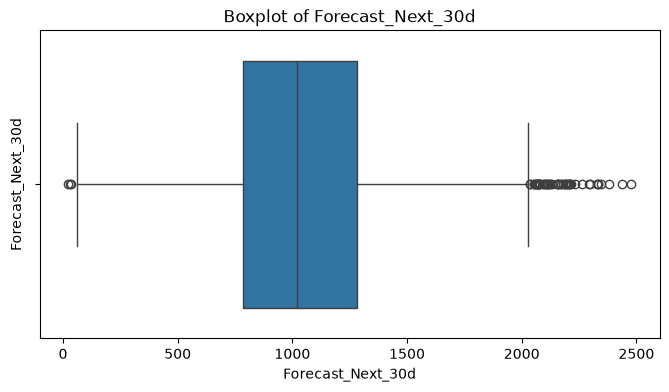

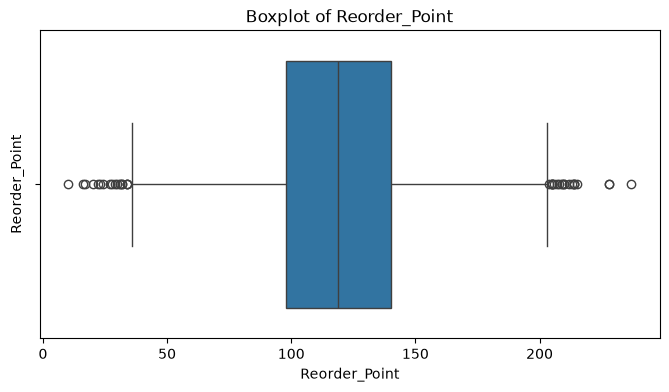

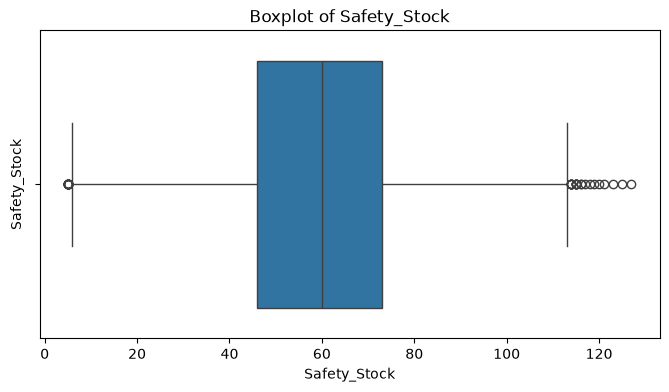

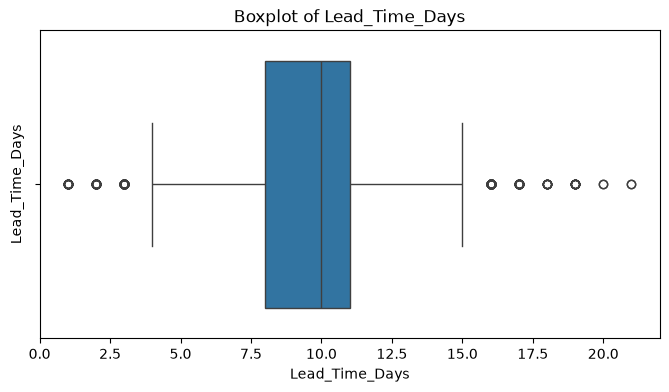

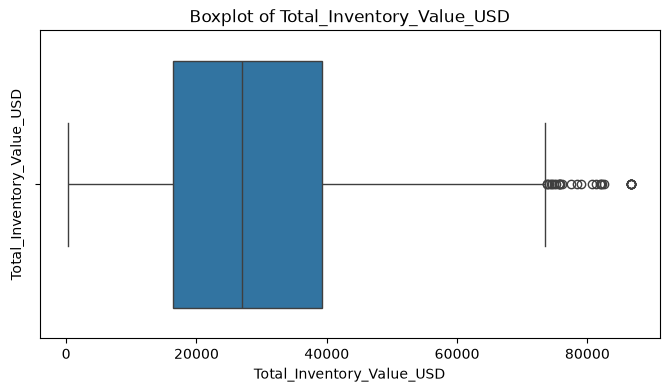

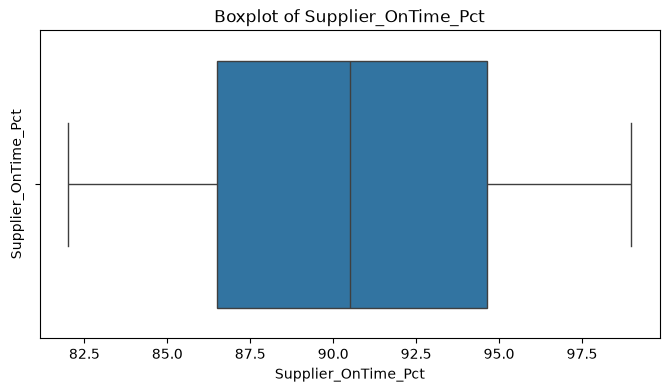

In [36]:
for col in numeric_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.boxplot(
        data=df,
        x=col
    )
    
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    
    plt.savefig(f"../reports/figures/{col}_boxplot.png")
    
    plt.show()

In [37]:
categorical_cols = [
    'Category',
    'ABC_Class',
    'Supplier_Name',
    'Warehouse_Location',
    'Inventory_Status'
]

In [60]:
for col in categorical_cols:
    
    print(" ")
    print(f"Frequency Table: {col}")
    
    print(df[col].value_counts())

 
Frequency Table: Category
Category
Produce          869
Snacks           856
Dairy            841
Beverages        829
Frozen Foods     829
Bakery           827
Personal Care    826
Household        823
Name: count, dtype: int64
 
Frequency Table: ABC_Class
ABC_Class
A    2290
B    2237
C    2173
Name: count, dtype: int64
 
Frequency Table: Supplier_Name
Supplier_Name
Prime Distribution      1132
Metro Supply Co         1129
Global Retail Supply    1125
NextGen Traders         1122
Urban Wholesale         1099
FreshMart Suppliers     1093
Name: count, dtype: int64
 
Frequency Table: Warehouse_Location
Warehouse_Location
Kolkata Warehouse      1367
Chennai Warehouse      1364
Delhi Warehouse        1344
Mumbai Warehouse       1335
Bangalore Warehouse    1290
Name: count, dtype: int64
 
Frequency Table: Inventory_Status
Inventory_Status
Normal       1758
Critical     1660
Low Stock    1648
Overstock    1634
Name: count, dtype: int64


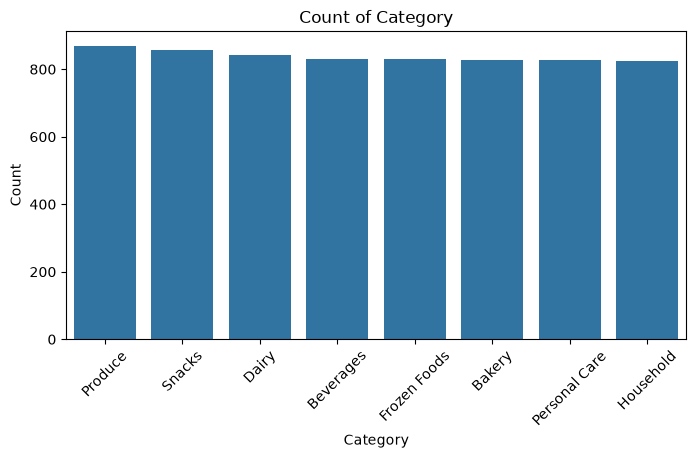

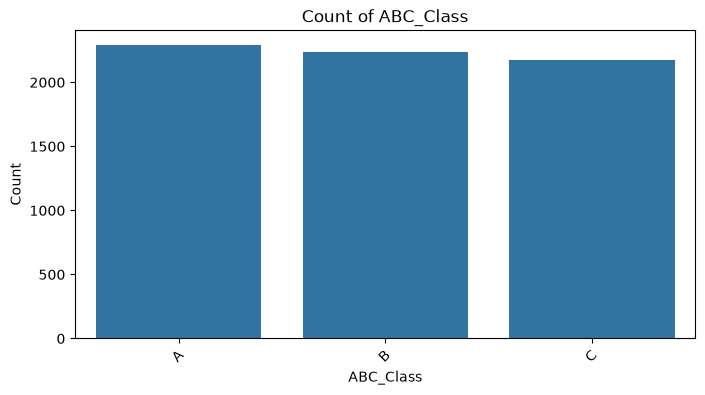

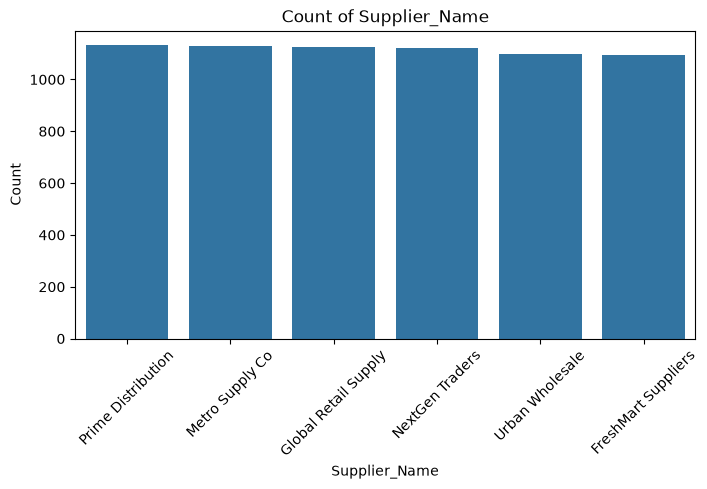

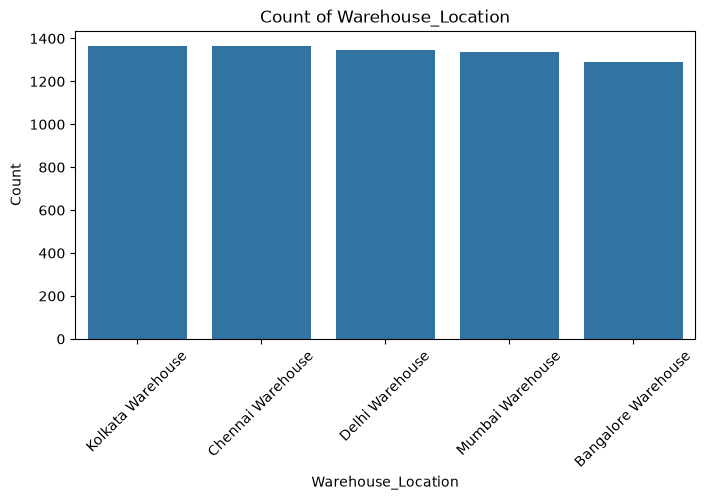

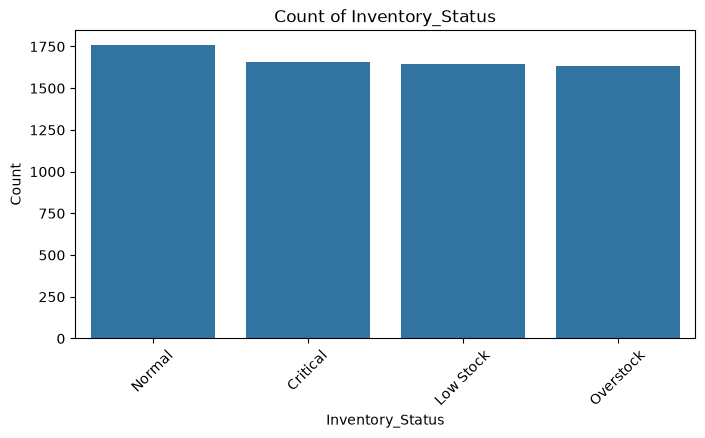

In [62]:
for col in categorical_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )
    
    plt.title(f"Count of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    
    plt.xticks(rotation=45)
    
    plt.savefig(f"../reports/figures/{col}_bar_chart.png",
                bbox_inches="tight")
    
    plt.show()

### Numeric ↔ Numeric

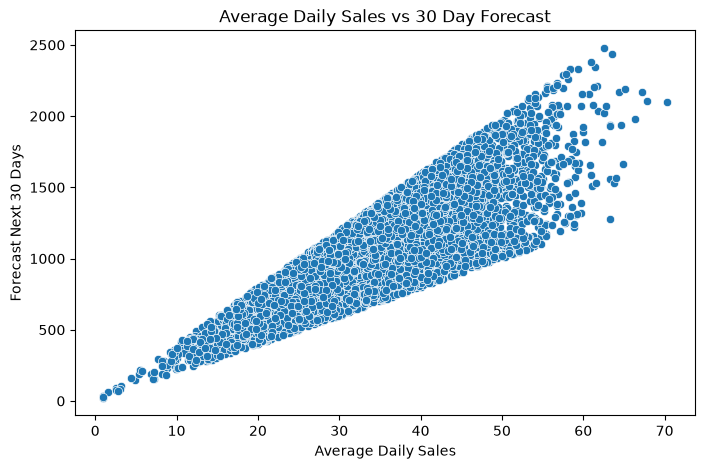

In [40]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Avg_Daily_Sales",
    y="Forecast_Next_30d"
)

plt.title("Average Daily Sales vs 30 Day Forecast")
plt.xlabel("Average Daily Sales")
plt.ylabel("Forecast Next 30 Days")

plt.savefig(
    "../reports/figures/avg_sales_vs_forecast.png",
    bbox_inches="tight"
)

plt.show()

## Correlation Heatmap

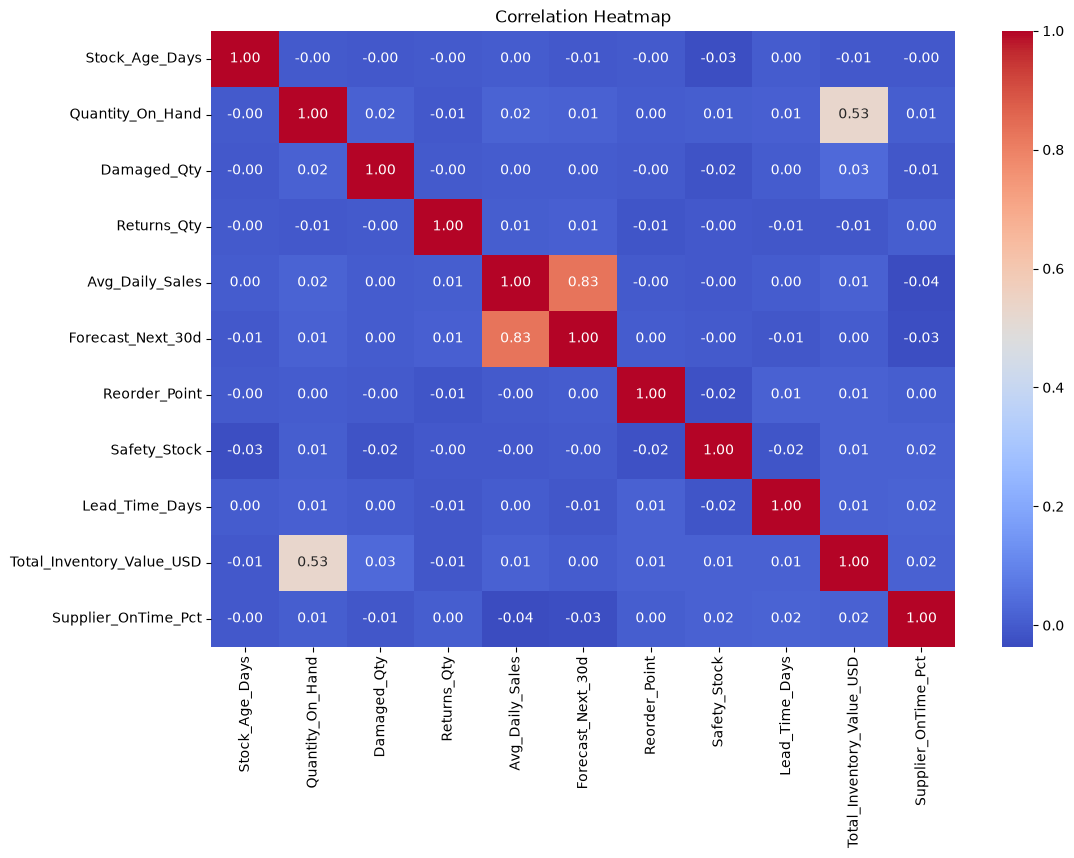

In [41]:
plt.figure(figsize=(12,8))

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "../reports/figures/correlation_heatmap.png",
    bbox_inches="tight"
)

plt.show()

## Numeric ↔ Categorical

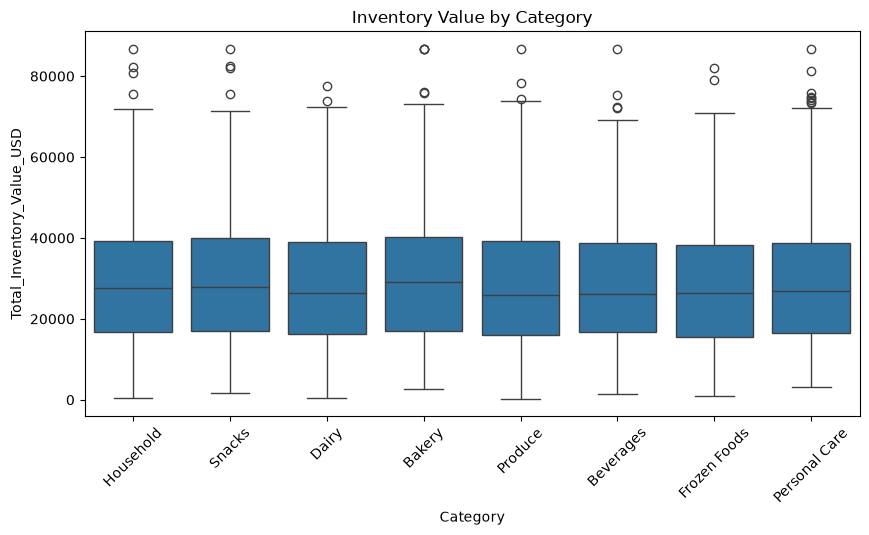

In [42]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="Category",
    y="Total_Inventory_Value_USD"
)

plt.title("Inventory Value by Category")
plt.xticks(rotation=45)

plt.savefig(
    "../reports/figures/inventory_value_by_category_boxplot.png",
    bbox_inches="tight"
)

plt.show()

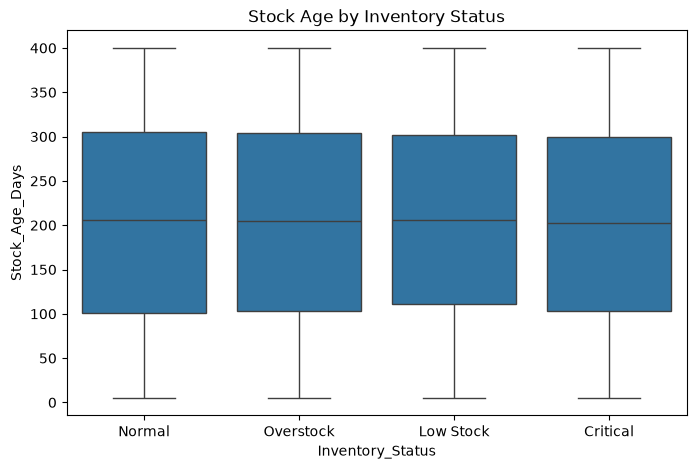

In [43]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Inventory_Status",
    y="Stock_Age_Days"
)

plt.title("Stock Age by Inventory Status")

plt.savefig(
    "../reports/figures/stock_age_by_status_boxplot.png",
    bbox_inches="tight"
)

plt.show()

## Segment Analysis

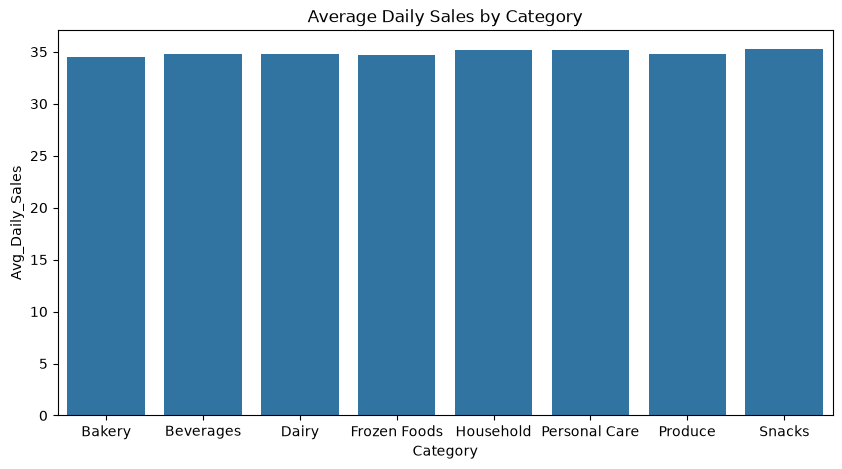

In [ ]:
category_sales = df.groupby("Category")["Avg_Daily_Sales"].mean().reset_index()

plt.figure(figsize=(10,5))

sns.barplot(
    data=category_sales,
    x="Category",
    y="Avg_Daily_Sales"a
)

plt.title("Average Daily Sales by Category")

plt.savefig(
    "../reports/figures/avg_daily_sales_by_category.png",
    bbox_inches="tight"
)

plt.show()

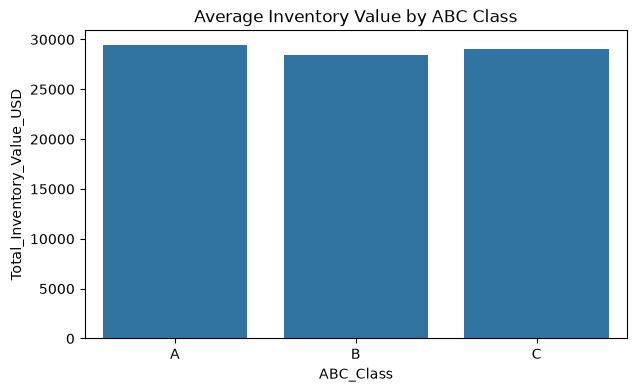

In [64]:
abc_analysis = df.groupby("ABC_Class")["Total_Inventory_Value_USD"].mean().reset_index()

plt.figure(figsize=(7,4))

sns.barplot(
    data=abc_analysis,
    x="ABC_Class",
    y="Total_Inventory_Value_USD"
)

plt.title("Average Inventory Value by ABC Class")

plt.savefig(
    "../reports/figures/inventory_value_by_abc_class.png",
    bbox_inches="tight"
)

plt.show()

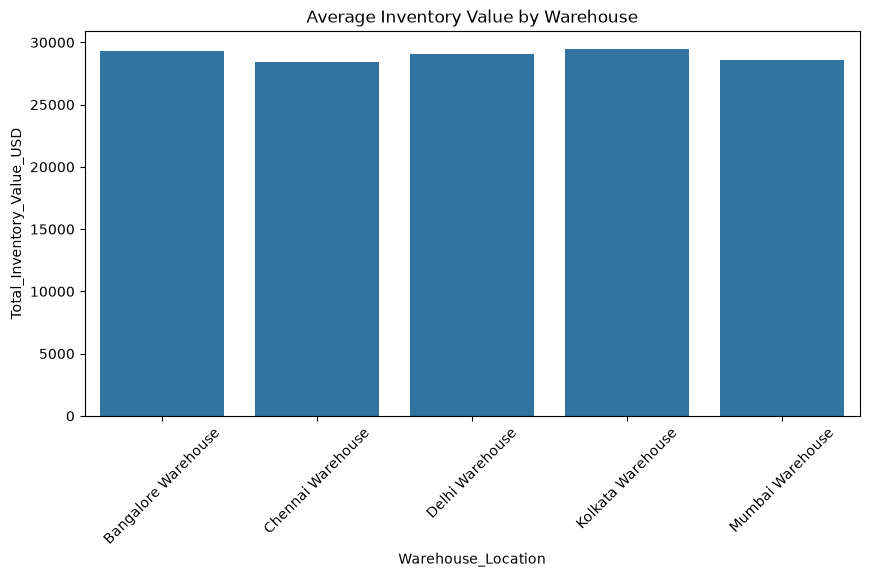

In [65]:
warehouse_analysis = df.groupby("Warehouse_Location")["Total_Inventory_Value_USD"].mean().reset_index()

plt.figure(figsize=(10,5))

sns.barplot(
    data=warehouse_analysis,
    x="Warehouse_Location",
    y="Total_Inventory_Value_USD"
)

plt.title("Average Inventory Value by Warehouse")

plt.xticks(rotation=45)

plt.savefig(
    "../reports/figures/inventory_value_by_warehouse.png",
    bbox_inches="tight"
)

plt.show()

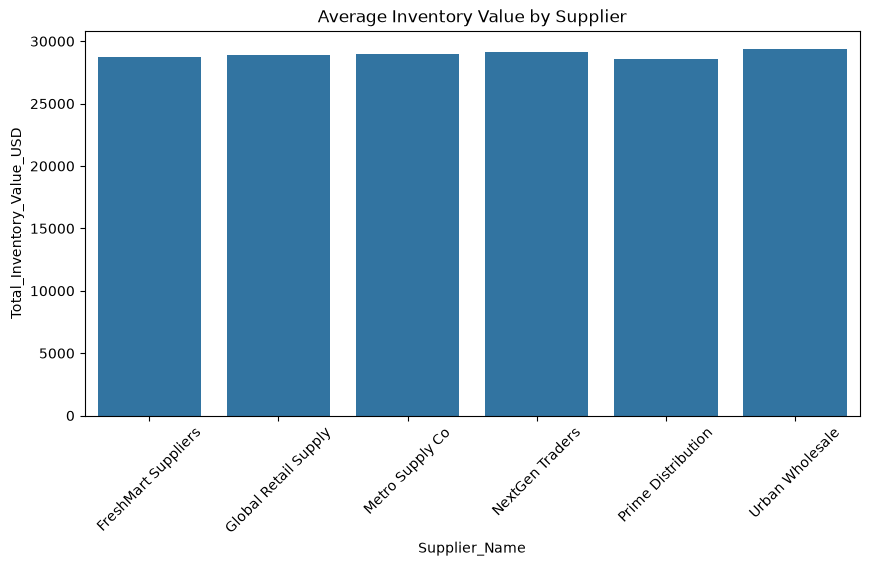

In [66]:
supplier_analysis = df.groupby("Supplier_Name")["Total_Inventory_Value_USD"].mean().reset_index()

plt.figure(figsize=(10,5))

sns.barplot(
    data=supplier_analysis,
    x="Supplier_Name",
    y="Total_Inventory_Value_USD"
)

plt.title("Average Inventory Value by Supplier")

plt.xticks(rotation=45)

plt.savefig(
    "../reports/figures/inventory_value_by_supplier.png",
    bbox_inches="tight"
)

plt.show()

In [67]:
df["Received_Date"] = pd.to_datetime(df["Received_Date"])
df["Last_Purchase_Date"] = pd.to_datetime(df["Last_Purchase_Date"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6700 entries, 0 to 6699
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   SKU_ID                     6700 non-null   str           
 1   Category                   6700 non-null   str           
 2   ABC_Class                  6700 non-null   str           
 3   Supplier_Name              6700 non-null   str           
 4   Warehouse_Location         6700 non-null   str           
 5   Received_Date              6700 non-null   datetime64[us]
 6   Last_Purchase_Date         6700 non-null   datetime64[us]
 7   Stock_Age_Days             6700 non-null   int64         
 8   Quantity_On_Hand           6700 non-null   float64       
 9   Damaged_Qty                6700 non-null   int64         
 10  Returns_Qty                6700 non-null   int64         
 11  Avg_Daily_Sales            6700 non-null   float64       
 12  Forecast_Next_30d

In [68]:
df["Received_Year"] = df["Received_Date"].dt.year
df["Received_Month"] = df["Received_Date"].dt.month

df["Purchase_Year"] = df["Last_Purchase_Date"].dt.year
df["Purchase_Month"] = df["Last_Purchase_Date"].dt.month

df.head()

,SKU_ID,Category,ABC_Class,Supplier_Name,Warehouse_Location,Received_Date,Last_Purchase_Date,Stock_Age_Days,Quantity_On_Hand,Damaged_Qty,...,Reorder_Point,Safety_Stock,Lead_Time_Days,Total_Inventory_Value_USD,Supplier_OnTime_Pct,Inventory_Status,Received_Year,Received_Month,Purchase_Year,Purchase_Month
0,SKU_14996,Household,A,NextGen Traders,Chennai Warehouse,2024-06-11,2024-07-11,212,482.0,13,...,126,47,7.0,45555.63,82.64,Normal,2024,6,2024,7
1,SKU_10247,Snacks,C,NextGen Traders,Bangalore Warehouse,2024-11-24,2025-03-19,357,640.0,8,...,110,75,5.0,36577.48,94.58,Normal,2024,11,2025,3
2,SKU_16215,Dairy,C,NextGen Traders,Chennai Warehouse,2023-02-01,2023-03-06,104,538.0,5,...,118,66,12.0,23742.67,98.22,Overstock,2023,2,2023,3
3,SKU_13545,Bakery,A,Prime Distribution,Chennai Warehouse,2024-03-13,2024-06-04,161,530.0,9,...,119,11,8.0,49287.57,97.45,Low Stock,2024,3,2024,6
4,SKU_15397,Produce,B,Global Retail Supply,Chennai Warehouse,2023-05-01,2023-05-09,289,397.0,14,...,128,42,3.0,16929.86,86.75,Overstock,2023,5,2023,5


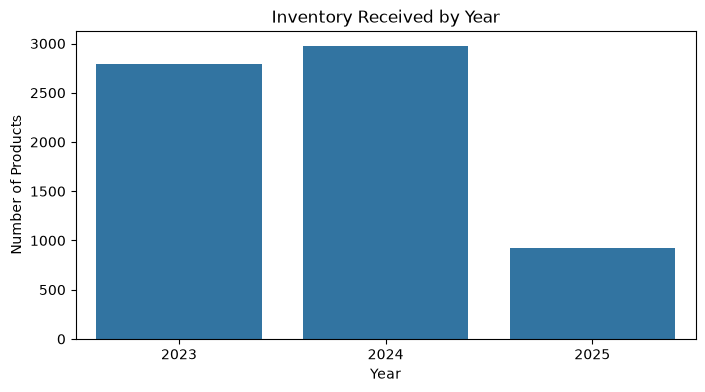

In [69]:
year_analysis = df["Received_Year"].value_counts().sort_index()

plt.figure(figsize=(8,4))

sns.barplot(
    x=year_analysis.index,
    y=year_analysis.values
)

plt.title("Inventory Received by Year")
plt.xlabel("Year")
plt.ylabel("Number of Products")

plt.savefig(
    "../reports/figures/inventory_received_by_year.png",
    bbox_inches="tight"
)

plt.show()

## EDA Key Findings

1. Inventory data contains 6700 records and 19 columns after preprocessing.

2. Numeric analysis showed the distribution and outliers in:
   - Stock age
   - Inventory value
   - Sales
   - Quantity levels

3. Category analysis showed differences between:
   - Product categories
   - ABC classifications
   - Warehouse locations
   - Suppliers

4. Correlation analysis helped identify relationships between inventory-related variables.

5. Segment analysis showed how inventory value varies across:
   - ABC classes
   - Warehouses
   - Suppliers

6. Date analysis provided insights into inventory receiving patterns over time.